In [ ]:
# Plot up differences in environmental parameters between the NCBI data available online and the information in the discrete data file
# Krista 8 September 2026

In [31]:
%reset -f

In [32]:
#not good practice, but I don't want this script in GitHub
%cd "D:\\Dropbox\\GitHub_niskin\\SargassoDB"

D:\Dropbox\GitHub_niskin\SargassoDB


d:\Dropbox\GitHub_niskin\SargassoDB\venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [33]:
from sqlalchemy import select, func, create_engine, text, union_all, union
from sqlalchemy.orm import sessionmaker, Session
from sqlalchemy import inspect, MetaData, Table
import pandas as pd
import matplotlib.pyplot as plt

import pdb

import models 
#from models import *
# import models as m

In [34]:
# create a SQLite database engine
SQLALCHEMY_DATABASE_URL = "sqlite:///test_data/sargasso.db"
engine = create_engine(SQLALCHEMY_DATABASE_URL) #, echo=True) #(turn off echo, gets annoying)

# Create a session
Session = sessionmaker(bind=engine)
session = Session()

In [35]:
from sqlalchemy import select

# Define your models and their prefixes
model_configs = [
    (models.Discrete, 'D'),
    (models.NCBIonline, 'N')
]

select_columns = []

for model, prefix in model_configs:
    # Loop through every column mapped to the model's table
    for column in model.__table__.columns:
        
        # 1. Skip or keep specific names without labels (e.g., keys or contact fields)
        if column.name in ['bottleID', 'contact']:
            select_columns.append(column)
            
        # 2. Handle edge cases where column names differ slightly between models
        elif column.name == 'nominalDepth':
            select_columns.append(column.label(f"{prefix}depth"))
            
        # 3. Automatically label everything else (e.g., temp -> Dtemp, sal -> Dsal)
        else:
            select_columns.append(column.label(f"{prefix}{column.name}"))

# Execute the query with the unpacked list
query = (
    select(*select_columns)
    .join(
        models.NCBIinhouse, 
        models.Discrete.bottleID == models.NCBIinhouse.bottleID
    )
    .join(
        models.NCBIonline, 
        models.NCBIinhouse.biosample == models.NCBIonline.biosample
    )
)
df = pd.read_sql_query(query, con=engine)
df.shape

(1009, 28)

In [ ]:
makeNumber = ['temp','sal','depth','oxy','fluor','density','lat','lon']
im = [col for col in df.columns if any(kw in col.lower() for kw in makeNumber) ] 
df[im] = df[im].apply(pd.to_numeric, errors='coerce')
im

['Dlat',
 'Dlon',
 'Ddepth',
 'Dtemp',
 'Dsal',
 'Doxy',
 'Ddensity',
 'Dfluor',
 'Ndepth',
 'Nlat',
 'Nlon',
 'Ntemp',
 'Nsal',
 'Nfluor',
 'Ndensity',
 'Noxy']

In [41]:
df['contact'].unique()

array(['Luis Bolanos', 'Fabian Wittmers', 'Shuting Liu',
       'Leocadio Blanco-Bercial'], dtype=object)

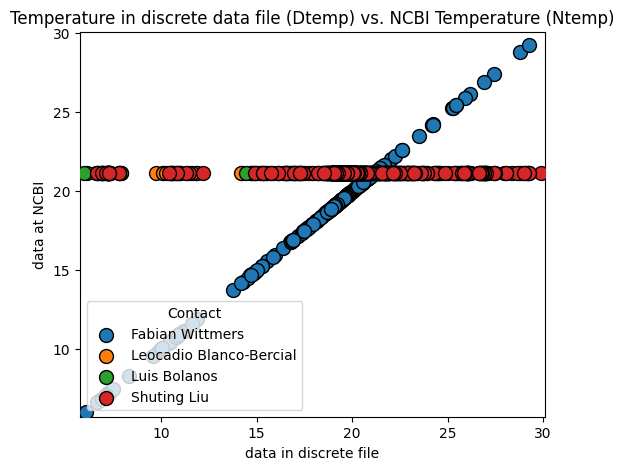

In [43]:
plt.figure(figsize=(6, 5))

# 1. Loop through unique categories in the contact column
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dtemp"], 
        group["Ntemp"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # 2. Add a 1:1 reference line
# min_val = min(df["Dtemp"].min(), df["Ntemp"].min()) - 0.2
# max_val = max(df["Dtemp"].max(), df["Ntemp"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 3. Labeling and grid (plt.legend() will now show the text categories)
plt.title("Temperature in discrete data file (Dtemp) vs. NCBI Temperature (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(title="Contact",loc='lower left')

plt.show()


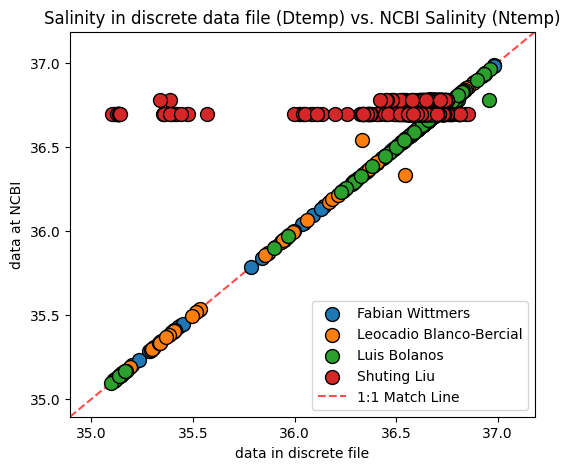

In [ ]:
# and salinity 
plt.figure(figsize=(6, 5))
# Loop through unique categories in the contact column
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dsal"], 
        group["Nsal"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# Add a 1:1 reference line to see where they perfectly match
min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Salinity in discrete data file (Dtemp) vs. NCBI Salinity (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

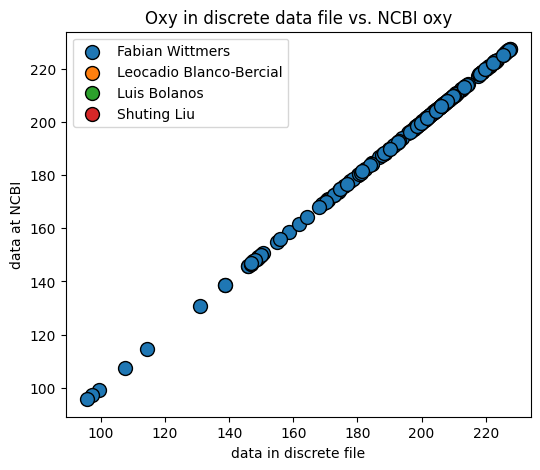

In [ ]:
# Scatter plot to compare the two oxygen ...only Fabian entered oxygen data
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Doxy"], 
        group["Noxy"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Oxy in discrete data file vs. NCBI oxy")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

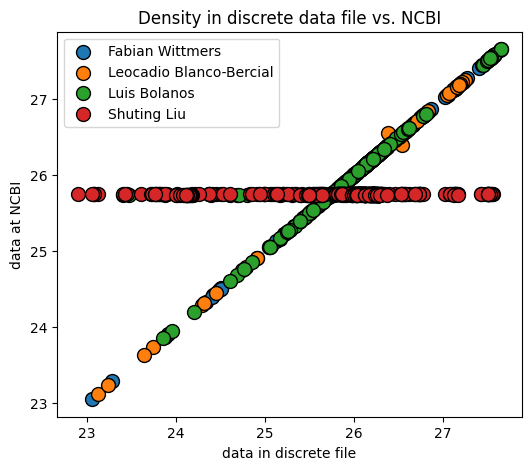

In [ ]:
# Scatter plot to compare the density
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Ddensity"], 
        group["Ndensity"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Density in discrete data file vs. NCBI")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

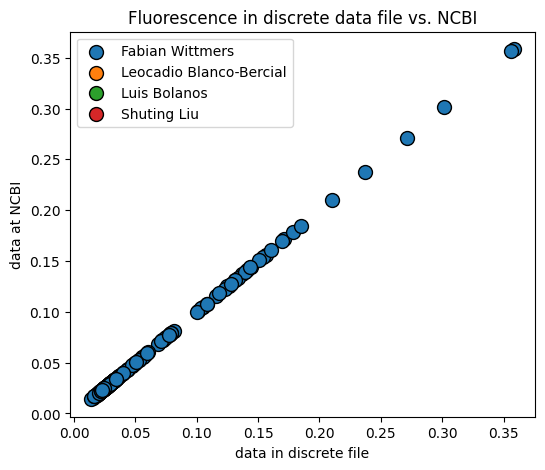

In [ ]:
# fluorescence - again only Fabian
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dfluor"], 
        group["Nfluor"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Fluorescence in discrete data file vs. NCBI")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

In [ ]:
#too annoying to plot lat/lon as zero,
# mz = ['Nlat','Nlon','Dlat','Dlon']
# df[mz] = df[mz].fillna(0)

# count the number of times I find None in lat/lon in NCBI data (all OK in the discrete file)
# Group by your tracking column, isolate column 'X', check for missing values, and sum them up
none_counts = df.groupby('contact')['Nlat'].apply(lambda x: x.isna().sum())
print(none_counts)

contact
Fabian Wittmers              0
Leocadio Blanco-Bercial      0
Luis Bolanos                 0
Shuting Liu                361
Name: Nlat, dtype: int64


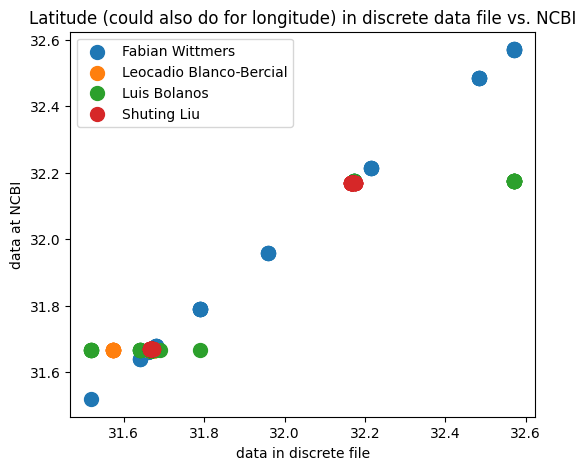

In [ ]:
# Latitude (plot would look similar for longitude)
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dlat"], 
        group["Nlat"], 
        label=name,     # Automatically handles the legend labels
        edgecolor=None, 
        s=100, 
        zorder=3
    )


# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Latitude (could also do for longitude) in discrete data file vs. NCBI")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

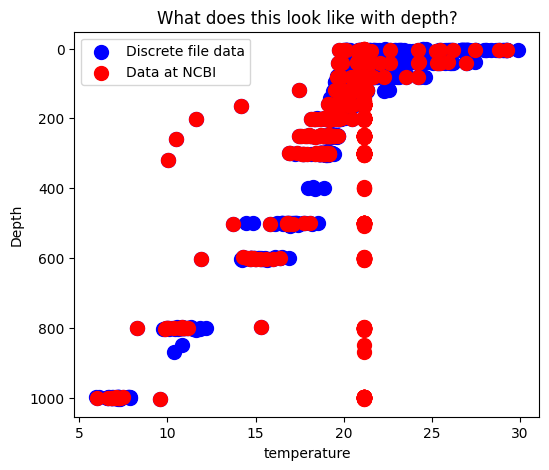

In [ ]:
# Plot with depth
plt.figure(figsize=(6, 5))
plt.scatter(df["Dtemp"], df["Ddepth"], color="blue", edgecolor="blue", s=100, zorder=3,label='Discrete file data')
plt.scatter(df["Ntemp"], df["Ddepth"], color="red", edgecolor="red", s=100, zorder=3,label= 'Data at NCBI')

# Labeling and grid
plt.title("What does this look like with depth?")
plt.xlabel("temperature")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

In [54]:
#Stick some code below this spot as a holding zone
raise SystemExit("Stop execution here")

SystemExit: Stop execution here

d:\Dropbox\GitHub_niskin\SargassoDB\venv\lib\site-packages\IPython\core\interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Scatter plot to compare the two temperatures
plt.figure(figsize=(6, 5))
plt.scatter(df["Dtemp"], df["Ntemp"], color="blue", edgecolor="k", s=100, zorder=3)

# Add a 1:1 reference line to see where they perfectly match
min_val = min(df["Dtemp"].min(), df["Ntemp"].min()) - 0.2
max_val = max(df["Dtemp"].max(), df["Ntemp"].max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Temperature in discrete data file (Dtemp) vs. NCBI Temperature (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

In [ ]:
#need something in case the contact is not listed 
df['contact']= df['contact'].fillna('unknown')